##Setup

In [1]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [2]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)

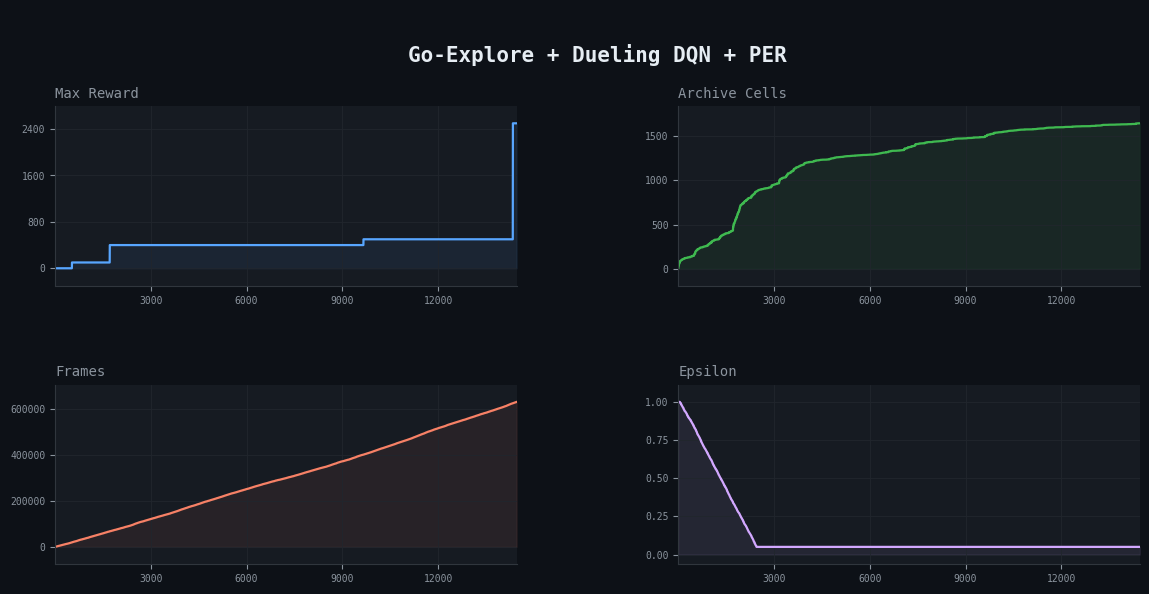

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'frames', 'epsilon'],
    title='Go-Explore + Dueling DQN + PER', update_every=10,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Sum-tree
#
# A binary tree where:
#   - Leaves store individual transition priorities p_i
#   - Internal nodes store the sum of their subtree
#
# This gives two O(log n) operations needed by PER:
#   update(idx, priority)  — update one leaf and propagate up
#   sample(value)          — walk down from root to find the
#                            leaf whose cumulative prefix sum
#                            contains `value`
#
# Memory layout: nodes[0] is root, children of nodes[i] are
# nodes[2i+1] and nodes[2i+2]. Leaves occupy the last
# `capacity` positions.
# ──────────────────────────────────────────────
class SumTree:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.nodes    = np.zeros(2 * capacity - 1, dtype=np.float64)
        self.data     = [None] * capacity   # circular buffer of transitions
        self.write    = 0                   # next write position in leaves
        self.size     = 0                   # current number of stored transitions

    # ── Internal helpers ─────────────────────────────────────────────────────
    def _leaf_index(self, data_index: int) -> int:
        """Convert data buffer index → tree node index."""
        return data_index + self.capacity - 1

    def _propagate(self, tree_index: int, delta: float):
        """Propagate a priority change up to the root."""
        parent = (tree_index - 1) // 2
        self.nodes[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    # ── Public API ────────────────────────────────────────────────────────────
    def update(self, data_index: int, priority: float):
        """Set the priority of transition at data_index and update sums."""
        tree_index = self._leaf_index(data_index)
        delta = priority - self.nodes[tree_index]
        self.nodes[tree_index] = priority
        self._propagate(tree_index, delta)

    def add(self, priority: float, transition):
        """Insert a new transition with the given priority."""
        self.data[self.write] = transition
        self.update(self.write, priority)
        self.write = (self.write + 1) % self.capacity
        self.size  = min(self.size + 1, self.capacity)

    def sample(self, value: float):
        """
        Find the leaf whose prefix-sum range contains `value`.
        Returns (data_index, priority, transition).
        """
        node = 0   # start at root
        while node < self.capacity - 1:
            left  = 2 * node + 1
            right = left + 1
            if value <= self.nodes[left]:
                node = left
            else:
                value -= self.nodes[left]
                node   = right
        data_index = node - (self.capacity - 1)
        return data_index, self.nodes[node], self.data[data_index]

    @property
    def total(self) -> float:
        return float(self.nodes[0])


# ──────────────────────────────────────────────
# Prioritised Replay Buffer
#
# Replaces uniform random sampling with priority-weighted sampling.
#
# α (alpha): controls how much prioritisation is used.
#   α=0 → uniform sampling (standard replay buffer)
#   α=1 → full prioritisation by TD error
#   Typical value: 0.6
#
# β (beta): importance sampling exponent, corrects for the
#   sampling bias introduced by non-uniform sampling.
#   β=0 → no correction
#   β=1 → full correction
#   Annealed from beta_start → 1.0 over training so corrections
#   strengthen as the value function matures and large updates
#   early in training are less harmful.
#
# ε (epsilon_priority): small constant added to every TD error
#   before storing as a priority, ensuring no transition has
#   zero probability of being sampled.
# ──────────────────────────────────────────────
class PrioritisedReplayBuffer:
    def __init__(
        self,
        capacity         : int,
        alpha            : float = 0.6,
        beta_start       : float = 0.4,
        beta_end         : float = 1.0,
        beta_steps       : int   = 100_000,
        epsilon_priority : float = 1e-6,
    ):
        self.tree             = SumTree(capacity)
        self.capacity         = capacity
        self.alpha            = alpha
        self.beta             = beta_start
        self.beta_start       = beta_start
        self.beta_end         = beta_end
        self.beta_steps       = beta_steps
        self.epsilon_priority = epsilon_priority
        self.steps_done       = 0
        # New transitions get max priority so they're sampled at least once
        self._max_priority    = 1.0

    def push(self, state, action, reward, next_state, done):
        transition = (state, action, reward, next_state, done)
        self.tree.add(self._max_priority ** self.alpha, transition)

    def sample(self, batch_size: int):
        """
        Stratified sampling: divide total priority into batch_size equal
        segments and sample one transition from each. This gives better
        coverage than pure random weighted sampling.

        Returns transitions, their tree indices (needed for priority
        updates), and IS weights (used to correct the gradient).
        """
        self.steps_done += 1
        # Anneal β linearly from beta_start → beta_end
        self.beta = min(
            self.beta_end,
            self.beta_start + self.steps_done * (self.beta_end - self.beta_start) / self.beta_steps
        )

        indices     = []
        transitions = []
        priorities  = []

        segment = self.tree.total / batch_size
        for i in range(batch_size):
            lo = segment * i
            hi = segment * (i + 1)
            value = random.uniform(lo, hi)
            idx, priority, transition = self.tree.sample(value)
            # Guard against uninitialised tree slots (None transitions)
            while transition is None:
                value = random.uniform(0, self.tree.total)
                idx, priority, transition = self.tree.sample(value)
            indices.append(idx)
            priorities.append(priority)
            transitions.append(transition)

        # IS weights: w_i = (1/N · 1/P(i))^β, normalised by max weight
        # so the largest weight is always 1 (keeps gradient scale stable)
        probs      = np.array(priorities) / self.tree.total
        probs      = np.clip(probs, 1e-10, None)   # avoid log(0)
        weights    = (1.0 / (self.tree.size * probs)) ** self.beta
        weights   /= weights.max()

        states, actions, rewards, next_states, dones = zip(*transitions)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones),
            np.array(indices, dtype=np.int64),
            np.array(weights, dtype=np.float32),
        )

    def update_priorities(self, indices: np.ndarray, td_errors: np.ndarray):
        """Called after each gradient step with the new TD errors."""
        for idx, err in zip(indices, td_errors):
            priority = (abs(err) + self.epsilon_priority) ** self.alpha
            self.tree.update(idx, priority)
            self._max_priority = max(self._max_priority, priority)

    def __len__(self):
        return self.tree.size


# ──────────────────────────────────────────────
# Dueling DQN Network
# ──────────────────────────────────────────────
class DuelingDQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             nn.ReLU(),
        )
        with torch.no_grad():
            feature_size = self.conv(
                torch.zeros(1, *input_shape)
            ).reshape(1, -1).size(1)

        self.value_stream = nn.Sequential(
            nn.Linear(feature_size, 512), nn.ReLU(),
            nn.Linear(512, 1),
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(feature_size, 512), nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x        = x.float() / 255.
        features = self.conv(x).reshape(x.size(0), -1)
        value     = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


# ──────────────────────────────────────────────
# DQN Agent
# ──────────────────────────────────────────────
class DQNAgent:
    def __init__(
        self, env,
        replay_buffer_capacity = 50_000,
        batch_size             = 32,
        gamma                  = 0.99,
        lr                     = 1e-4,
        grad_clip              = 10.0,
        tau                    = 0.005,
        warmup_steps           = 1_000,
        epsilon_start          = 1.0,
        epsilon_end            = 0.05,
        epsilon_decay_steps    = 50_000,
        # PER hyperparameters
        per_alpha              = 0.6,
        per_beta_start         = 0.4,
        per_beta_end           = 1.0,
        per_beta_steps         = 100_000,
    ):
        self.env               = env
        self.action_space_size = env.action_space.n
        obs                    = env.observation_space.shape
        self.input_shape       = (obs[2], obs[0], obs[1])

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.policy_net = DuelingDQN(self.input_shape, self.action_space_size).to(self.device)
        self.target_net = DuelingDQN(self.input_shape, self.action_space_size).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer    = optim.Adam(self.policy_net.parameters(), lr=lr)
        # Swap uniform ReplayBuffer → PrioritisedReplayBuffer
        self.memory       = PrioritisedReplayBuffer(
            capacity    = replay_buffer_capacity,
            alpha       = per_alpha,
            beta_start  = per_beta_start,
            beta_end    = per_beta_end,
            beta_steps  = per_beta_steps,
        )
        self.batch_size   = batch_size
        self.gamma        = gamma
        self.grad_clip    = grad_clip
        self.tau          = tau
        self.warmup_steps = warmup_steps

        self.epsilon             = epsilon_start
        self.epsilon_start       = epsilon_start
        self.epsilon_end         = epsilon_end
        self.epsilon_decay_steps = epsilon_decay_steps
        self.steps_done          = 0

    def _preprocess(self, state):
        return torch.from_numpy(state).permute(2, 0, 1).unsqueeze(0).to(self.device)

    def select_action(self, state):
        self.steps_done += 1
        self.epsilon = max(
            self.epsilon_end,
            self.epsilon_start - self.steps_done / self.epsilon_decay_steps
        )
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        with torch.no_grad():
            return self.policy_net(self._preprocess(state)).argmax(1).item()

    def optimize_model(self):
        if len(self.memory) < max(self.batch_size, self.warmup_steps):
            return None

        # Unpack the extra (indices, is_weights) that PER returns
        states, actions, rewards, next_states, dones, indices, is_weights = \
            self.memory.sample(self.batch_size)

        states      = torch.from_numpy(states).permute(0, 3, 1, 2).to(self.device)
        next_states = torch.from_numpy(next_states).permute(0, 3, 1, 2).to(self.device)
        actions     = torch.from_numpy(actions).long().unsqueeze(1).to(self.device)
        rewards     = torch.from_numpy(rewards).float().unsqueeze(1).to(self.device)
        dones       = torch.from_numpy(dones.astype(np.float32)).unsqueeze(1).to(self.device)
        # IS weights correct for the non-uniform sampling bias
        is_weights  = torch.from_numpy(is_weights).float().unsqueeze(1).to(self.device)

        current_q = self.policy_net(states).gather(1, actions)

        # Double DQN target
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(1, keepdim=True)
            next_q       = self.target_net(next_states).gather(1, next_actions)
            target_q     = rewards + self.gamma * next_q * (1 - dones)

        # Per-transition TD errors (used to update priorities)
        td_errors = (target_q - current_q).detach().cpu().numpy().squeeze(1)

        # IS-weighted Huber loss:
        # multiply each transition's loss by its IS weight before averaging.
        # High-priority transitions have smaller weights to compensate for
        # being oversampled; low-priority transitions have weights near 1.
        element_loss = F.huber_loss(current_q, target_q, reduction='none', delta=1.0)
        loss         = (is_weights * element_loss).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), self.grad_clip)
        self.optimizer.step()

        # Update priorities in the sum-tree with fresh TD errors
        self.memory.update_priorities(indices, td_errors)

        # Soft target update
        for p_param, t_param in zip(self.policy_net.parameters(),
                                    self.target_net.parameters()):
            t_param.data.copy_(self.tau * p_param.data + (1 - self.tau) * t_param.data)

        return loss.item()

    def store(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()

def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
WARMUP_ITERS    = 50
STEPS_PER_ITER  = 100
EXPLORE_EPSILON = 0.5

archive      = defaultdict(lambda: Cell())
highscore    = 0
frames       = 0

env   = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
agent = DQNAgent(env)

state, _      = env.reset()
score         = 0
trajectory    = []
iterations    = 0
restore_cell  = None
current_lives = get_lives(env)

# ──────────────────────────────────────────────
# Main loop
# ──────────────────────────────────────────────
while True:
    found_new_cell = False

    for step in range(STEPS_PER_ITER):
        if iterations < WARMUP_ITERS or random.random() < EXPLORE_EPSILON:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state)

        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost

        if iterations >= WARMUP_ITERS:
            agent.store(state, action, reward, next_state, done)
            agent.optimize_model()

        score += reward
        trajectory.append(action)
        frames += 1
        current_lives = new_lives

        if score > highscore:
            highscore = score

        if done:
            score         = 0
            trajectory    = []
            state, _      = env.reset()
            current_lives = get_lives(env)
            break
        else:
            cell_repr   = cellfn(next_state)
            cellhash    = hashfn(cell_repr)
            cell        = archive[cellhash]
            first_visit = cell.visit()

            cell_reward = getattr(cell, 'reward',     -1e9)
            cell_traj   = getattr(cell, 'trajectory', [])
            better  = score > cell_reward
            shorter = score == cell_reward and len(trajectory) < len(cell_traj)

            if first_visit or better or shorter:
                cell.ram        = env.unwrapped.ale.cloneState()
                cell.reward     = score
                cell.trajectory = trajectory.copy()
                cell.times_chosen           = 0
                cell.times_chosen_since_new = 0
                found_new_cell = True

            state = next_state

    if found_new_cell and restore_cell is not None:
        restore_cell.times_chosen_since_new = 0

    iterations += 1

    if len(archive) > 0:
        scores      = np.array([c.score for c in archive.values()])
        hashes      = list(archive.keys())
        probs       = scores / scores.sum()
        chosen_hash = np.random.choice(hashes, p=probs)
        restore_cell = archive[chosen_hash]
        ram, score, trajectory = restore_cell.choose()
        state         = restore_env(env, ram)
        current_lives = get_lives(env)
    else:
        state, _      = env.reset()
        score         = 0
        trajectory    = []
        current_lives = get_lives(env)

    dashboard.update(
        iteration=iterations, frames=frames,
        max_reward=highscore, cells=len(archive),
        epsilon=agent.epsilon,
    )